### Three qubit phase-flip code

Now we have a channel which with probability $p$ changes qubit $a \ket{0} + b \ket{1} $ to $a \ket{0} - b \ket{1}$ (that is, applies gate Z), and w.p. (1-p) leaves it unchanged.

Let's see that using the three-qubit bit-flip protocol doesn't give any error correction.

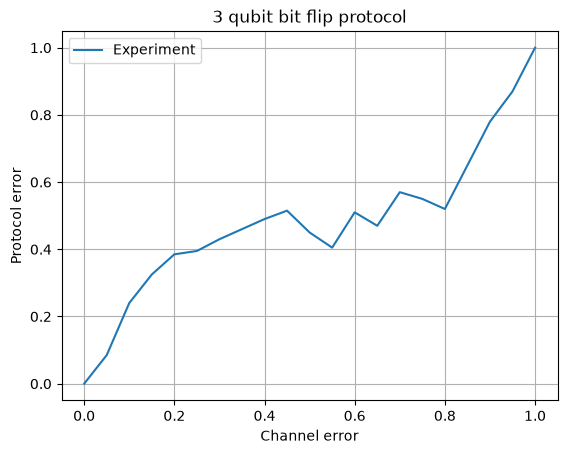

Time: 6.88s


In [1]:
from error_correction.channels import PhaseFlipChannel
from error_correction.protocols import ThreeQubitBitFlipProtocol, ThreeQubitPhaseFlipProtocol
from error_correction.utils import test_protocol_once, plot_errors

plot_errors(ThreeQubitBitFlipProtocol(), 
            num_points=21, 
            num_experiments=200,
            channel_factory=lambda p:PhaseFlipChannel(p))

Now recall that Z = HXH, and HZH = X. This means that if we apply a Hadamard gate before and after the channel, this channel becomes a bit-flip channel.

So, we can use the same error-correcting protocol, except we need to apply H gate after encoding and before decoding.

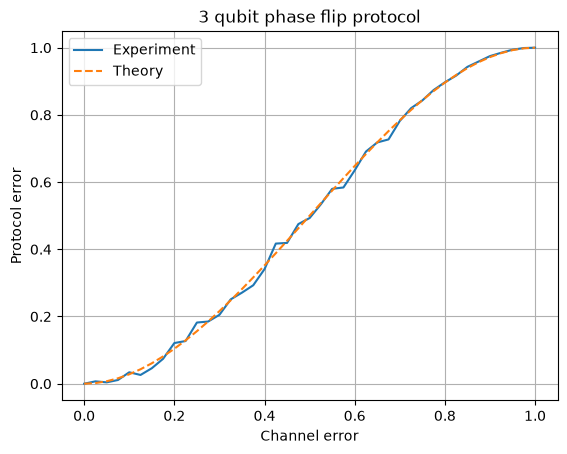

Time: 106.97s


In [2]:
plot_errors(ThreeQubitPhaseFlipProtocol(), 
            num_points=41, 
            num_experiments=1000,
            channel_factory=lambda p:PhaseFlipChannel(p),
            theoretical=lambda x:3*x**2*(1-x)+x**3)